In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout, Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json 

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd

path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดไฟล์
X_train = pd.read_csv(f'{path}X_train_80.csv')
X_test = pd.read_csv(f'{path}X_test_20.csv')
y_train = pd.read_csv(f'{path}y_train_80.csv').squeeze()
y_test = pd.read_csv(f'{path}y_test_20.csv').squeeze()

print("✅ โหลดชุดข้อมูล 80:20 เรียบร้อย!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

✅ โหลดชุดข้อมูล 80:20 เรียบร้อย!
Train shape: (8000, 20)
Test shape: (2000, 20)


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ฟังก์ชันสร้าง ResNet Block
def residual_block(x, units, dropout_rate=0.2):
    shortcut = x
    
    # Layer 1
    x = Dense(units)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    # Layer 2
    x = Dense(units)(x)
    x = BatchNormalization()(x)
    
    # Skip Connection (หัวใจสำคัญของ ResNet)
    # ถ้าขนาดไม่เท่ากัน ปรับขนาด shortcut ให้เท่ากันก่อนบวก
    if shortcut.shape[-1] != units:
        shortcut = Dense(units)(shortcut)
        
    x = Add()([x, shortcut]) # บวกค่าเดิมกลับเข้าไป
    x = Activation('relu')(x)
    return x

# ฟังก์ชันสร้างโมเดลหลัก
def create_resnet_model(input_dim):
    inputs = Input(shape=(input_dim,))
    
    # Project Input
    x = Dense(64)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Stack Residual Blocks (ต่อบล็อกซ้อนกัน)
    x = residual_block(x, units=64, dropout_rate=0.3)
    x = residual_block(x, units=32, dropout_rate=0.3)
    x = residual_block(x, units=16, dropout_rate=0.2)
    
    # Output Layer
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

print("✓ ResNet Architecture Created!")

✓ ResNet Architecture Created!


------------------------------
ResNet - Baseline (No Sampling)
------------------------------


Fold 1: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 2: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 3: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 4: Val Accuracy = 0.8000 (Recall: 0.0000)


Fold 5: Val Accuracy = 0.8000 (Recall: 0.0000)
Selected model from fold 1 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8000    1.0000    0.8889      1600
           1     0.0000    0.0000    0.0000       400

    accuracy                         0.8000      2000
   macro avg     0.4000    0.5000    0.4444      2000
weighted avg     0.6400    0.8000    0.7111      2000

Confusion Matrix:
 [[1600    0]
 [ 400    0]]


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

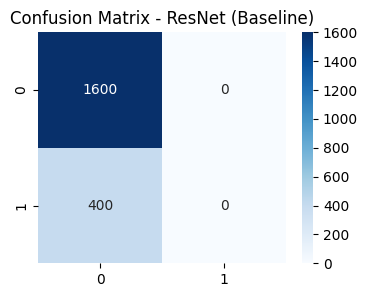

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✓ ResNet Baseline Done


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("-" * 30)
print('ResNet - Baseline (No Sampling)')
print("-" * 30)

best_model_resnet_base = None
best_score_resnet_base = 0
best_fold_idx_resnet_base = -1
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # สร้างโมเดล ResNet
    model = create_resnet_model(X_fold_train.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # Train
    model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # Evaluate
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    if accuracy > best_score_resnet_base:
        best_score_resnet_base = accuracy
        best_model_resnet_base = model
        best_fold_idx_resnet_base = fold

# Test Set Evaluation
print(f"Selected model from fold {best_fold_idx_resnet_base} for test evaluation")
y_pred_proba = best_model_resnet_base.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet (Baseline)')
plt.show()

resnet_baseline_results = {
    'Model': 'ResNet',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred),
    'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3],
    'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1],
    'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}

# Save
os.makedirs('resnet/models', exist_ok=True)
best_model_resnet_base.save('resnet/models/ResNet_baseline_bestfold.h5')
print("✓ ResNet Baseline Done")

------------------------------
ResNet + SMOTE
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.6356


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.6706


...

Fold 3: Val Accuracy = 0.5875


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6544


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6538
Selected model from fold 2 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8028    0.7788    0.7906      1600
           1     0.2098    0.2350    0.2217       400

    accuracy                         0.6700      2000
   macro avg     0.5063    0.5069    0.5062      2000
weighted avg     0.6842    0.6700    0.6768      2000

Confusion Matrix:
 [[1246  354]
 [ 306   94]]


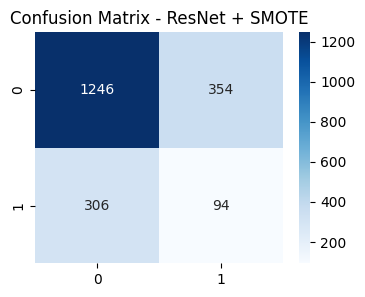

✓ Done: ResNet + SMOTE


In [5]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('ResNet + SMOTE')
print("-" * 30)

best_model_resnet_smote = None
best_score_resnet_smote = 0
best_fold_idx_resnet_smote = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_smote:
        best_score_resnet_smote = accuracy
        best_model_resnet_smote = model
        best_fold_idx_resnet_smote = fold

print(f"Selected model from fold {best_fold_idx_resnet_smote} for test evaluation")
y_pred_proba = best_model_resnet_smote.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + SMOTE')
plt.show()

resnet_smote_results = {
    'Model': 'ResNet', 'Sampling': f'SMOTE (Fold {best_fold_idx_resnet_smote})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_smote.save('resnet/models/ResNet_smote_bestfold.h5')
print("✓ Done: ResNet + SMOTE")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
ResNet + ADASYN
------------------------------


Fold 1: Val Accuracy = 0.6556


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.6706


...

Fold 3: Val Accuracy = 0.6675


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6206


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6519
Selected model from fold 2 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7963    0.7575    0.7764      1600
           1     0.1883    0.2250    0.2050       400

    accuracy                         0.6510      2000
   macro avg     0.4923    0.4912    0.4907      2000
weighted avg     0.6747    0.6510    0.6621      2000

Confusion Matrix:
 [[1212  388]
 [ 310   90]]


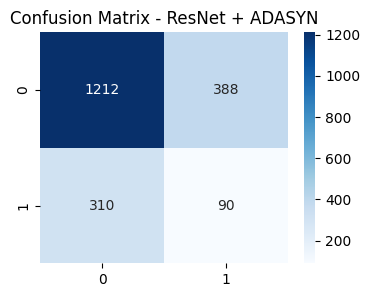

✓ Done: ResNet + ADASYN


In [6]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('ResNet + ADASYN')
print("-" * 30)

best_model_resnet_adasyn = None
best_score_resnet_adasyn = 0
best_fold_idx_resnet_adasyn = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    adasyn = ADASYN(random_state=42)
    X_res, y_res = adasyn.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_adasyn:
        best_score_resnet_adasyn = accuracy
        best_model_resnet_adasyn = model
        best_fold_idx_resnet_adasyn = fold

print(f"Selected model from fold {best_fold_idx_resnet_adasyn} for test evaluation")
y_pred_proba = best_model_resnet_adasyn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + ADASYN')
plt.show()

resnet_adasyn_results = {
    'Model': 'ResNet', 'Sampling': f'ADASYN (Fold {best_fold_idx_resnet_adasyn})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_adasyn.save('resnet/models/ResNet_adasyn_bestfold.h5')
print("✓ Done: ResNet + ADASYN")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


------------------------------
ResNet + RandomUnderSampler
------------------------------


Fold 1: Val Accuracy = 0.5631


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 2: Val Accuracy = 0.6931


...

Fold 3: Val Accuracy = 0.5481


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 4: Val Accuracy = 0.3825


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Fold 5: Val Accuracy = 0.5856
Selected model from fold 2 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7996    0.8106    0.8051      1600
           1     0.1984    0.1875    0.1928       400

    accuracy                         0.6860      2000
   macro avg     0.4990    0.4991    0.4989      2000
weighted avg     0.6794    0.6860    0.6826      2000

Confusion Matrix:
 [[1297  303]
 [ 325   75]]


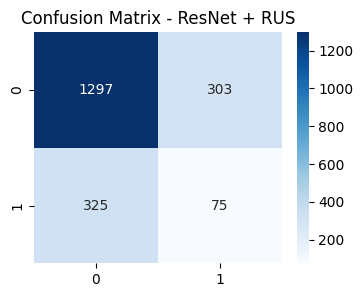

✓ Done: ResNet + RUS


In [7]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('ResNet + RandomUnderSampler')
print("-" * 30)

best_model_resnet_rus = None
best_score_resnet_rus = 0
best_fold_idx_resnet_rus = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    rus = RandomUnderSampler(random_state=42)
    X_res, y_res = rus.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_rus:
        best_score_resnet_rus = accuracy
        best_model_resnet_rus = model
        best_fold_idx_resnet_rus = fold

print(f"Selected model from fold {best_fold_idx_resnet_rus} for test evaluation")
y_pred_proba = best_model_resnet_rus.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + RUS')
plt.show()

resnet_rus_results = {
    'Model': 'ResNet', 'Sampling': f'RandomUnderSampler (Fold {best_fold_idx_resnet_rus})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_rus.save('resnet/models/ResNet_rus_bestfold.h5')
print("✓ Done: ResNet + RUS")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
ResNet + NearMiss
------------------------------


Fold 1: Val Accuracy = 0.3806


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5875


...

Fold 3: Val Accuracy = 0.5256


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5275


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5875
Selected model from fold 2 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8078    0.6512    0.7211      1600
           1     0.2141    0.3800    0.2739       400

    accuracy                         0.5970      2000
   macro avg     0.5109    0.5156    0.4975      2000
weighted avg     0.6890    0.5970    0.6317      2000

Confusion Matrix:
 [[1042  558]
 [ 248  152]]


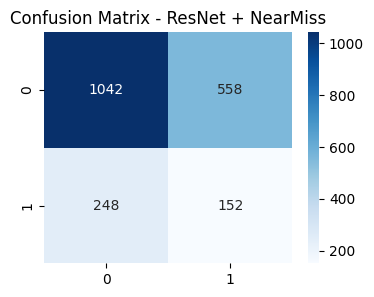

✓ Done: ResNet + NearMiss


In [8]:
from imblearn.under_sampling import NearMiss

print("-" * 30)
print('ResNet + NearMiss')
print("-" * 30)

best_model_resnet_nm = None
best_score_resnet_nm = 0
best_fold_idx_resnet_nm = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    nm = NearMiss(version=1)
    X_res, y_res = nm.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_nm:
        best_score_resnet_nm = accuracy
        best_model_resnet_nm = model
        best_fold_idx_resnet_nm = fold

print(f"Selected model from fold {best_fold_idx_resnet_nm} for test evaluation")
y_pred_proba = best_model_resnet_nm.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + NearMiss')
plt.show()

resnet_nearmiss_results = {
    'Model': 'ResNet', 'Sampling': f'NearMiss (Fold {best_fold_idx_resnet_nm})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_nm.save('resnet/models/ResNet_nearmiss_bestfold.h5')
print("✓ Done: ResNet + NearMiss")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
ResNet + ClusterCentroids (Warning: Slow!)
------------------------------


Fold 1: Val Accuracy = 0.3713


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.4606


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.4425


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.4350
Selected model from fold 2 for test evaluation


--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8176    0.4537    0.5836      1600
           1     0.2140    0.5950    0.3148       400

    accuracy                         0.4820      2000
   macro avg     0.5158    0.5244    0.4492      2000
weighted avg     0.6969    0.4820    0.5298      2000

Confusion Matrix:
 [[726 874]
 [162 238]]


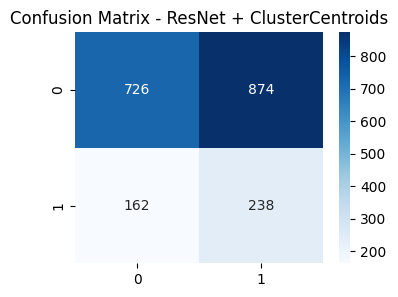

✓ Done: ResNet + ClusterCentroids


In [9]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('ResNet + ClusterCentroids (Warning: Slow!)')
print("-" * 30)

best_model_resnet_cc = None
best_score_resnet_cc = 0
best_fold_idx_resnet_cc = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    cc = ClusterCentroids(random_state=42)
    X_res, y_res = cc.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_cc:
        best_score_resnet_cc = accuracy
        best_model_resnet_cc = model
        best_fold_idx_resnet_cc = fold

print(f"Selected model from fold {best_fold_idx_resnet_cc} for test evaluation")
y_pred_proba = best_model_resnet_cc.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + ClusterCentroids')
plt.show()

resnet_cc_results = {
    'Model': 'ResNet', 'Sampling': f'ClusterCentroids (Fold {best_fold_idx_resnet_cc})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_cc.save('resnet/models/ResNet_cc_bestfold.h5')
print("✓ Done: ResNet + ClusterCentroids")

------------------------------
ResNet + SMOTETomek
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: Val Accuracy = 0.6687


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.6856


...

Fold 3: Val Accuracy = 0.6919


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.6256


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.7081
Selected model from fold 5 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7923    0.8275    0.8095      1600
           1     0.1611    0.1325    0.1454       400

    accuracy                         0.6885      2000
   macro avg     0.4767    0.4800    0.4775      2000
weighted avg     0.6661    0.6885    0.6767      2000

Confusion Matrix:
 [[1324  276]
 [ 347   53]]


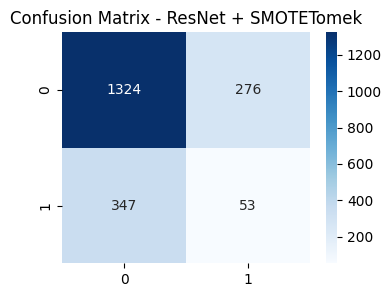

✓ Done: ResNet + SMOTETomek


In [10]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('ResNet + SMOTETomek')
print("-" * 30)

best_model_resnet_smt = None
best_score_resnet_smt = 0
best_fold_idx_resnet_smt = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    smt = SMOTETomek(random_state=42)
    X_res, y_res = smt.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_smt:
        best_score_resnet_smt = accuracy
        best_model_resnet_smt = model
        best_fold_idx_resnet_smt = fold

print(f"Selected model from fold {best_fold_idx_resnet_smt} for test evaluation")
y_pred_proba = best_model_resnet_smt.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + SMOTETomek')
plt.show()

resnet_smt_results = {
    'Model': 'ResNet', 'Sampling': f'SMOTETomek (Fold {best_fold_idx_resnet_smt})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_smt.save('resnet/models/ResNet_smotetomek_bestfold.h5')
print("✓ Done: ResNet + SMOTETomek")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
ResNet + SMOTEENN
------------------------------


Fold 1: Val Accuracy = 0.2850


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.2294


...

Fold 3: Val Accuracy = 0.2119


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.2750


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.3175
Selected model from fold 5 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8208    0.1631    0.2722      1600
           1     0.2039    0.8575    0.3295       400

    accuracy                         0.3020      2000
   macro avg     0.5123    0.5103    0.3008      2000
weighted avg     0.6974    0.3020    0.2836      2000

Confusion Matrix:
 [[ 261 1339]
 [  57  343]]


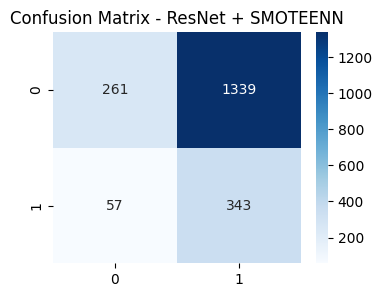

✓ Done: ResNet + SMOTEENN


In [11]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('ResNet + SMOTEENN')
print("-" * 30)

best_model_resnet_sme = None
best_score_resnet_sme = 0
best_fold_idx_resnet_sme = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    sme = SMOTEENN(random_state=42)
    X_res, y_res = sme.fit_resample(X_fold_train, y_fold_train)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_sme:
        best_score_resnet_sme = accuracy
        best_model_resnet_sme = model
        best_fold_idx_resnet_sme = fold

print(f"Selected model from fold {best_fold_idx_resnet_sme} for test evaluation")
y_pred_proba = best_model_resnet_sme.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + SMOTEENN')
plt.show()

resnet_sme_results = {
    'Model': 'ResNet', 'Sampling': f'SMOTEENN (Fold {best_fold_idx_resnet_sme})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_sme.save('resnet/models/ResNet_smoteenn_bestfold.h5')
print("✓ Done: ResNet + SMOTEENN")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
ResNet + ADASYN + Tomek Links
------------------------------


Fold 1: Val Accuracy = 0.6587


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.6550


...

Fold 3: Val Accuracy = 0.6031


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6294


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6825
Selected model from fold 5 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.8019    0.7719    0.7866      1600
           1     0.2065    0.2375    0.2209       400

    accuracy                         0.6650      2000
   macro avg     0.5042    0.5047    0.5038      2000
weighted avg     0.6829    0.6650    0.6735      2000

Confusion Matrix:
 [[1235  365]
 [ 305   95]]


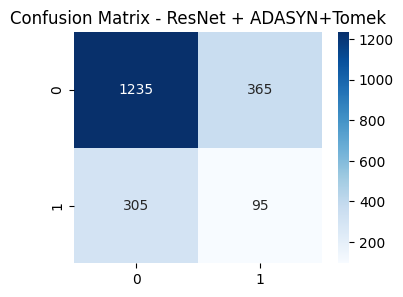

✓ Done: ResNet + ADASYN + Tomek


In [12]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('ResNet + ADASYN + Tomek Links')
print("-" * 30)

best_model_resnet_ada_tomek = None
best_score_resnet_ada_tomek = 0
best_fold_idx_resnet_ada_tomek = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    ada = ADASYN(random_state=42)
    X_res, y_res = ada.fit_resample(X_fold_train, y_fold_train)
    tl = TomekLinks()
    X_res, y_res = tl.fit_resample(X_res, y_res)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_ada_tomek:
        best_score_resnet_ada_tomek = accuracy
        best_model_resnet_ada_tomek = model
        best_fold_idx_resnet_ada_tomek = fold

print(f"Selected model from fold {best_fold_idx_resnet_ada_tomek} for test evaluation")
y_pred_proba = best_model_resnet_ada_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + ADASYN+Tomek')
plt.show()

resnet_ada_tomek_results = {
    'Model': 'ResNet', 'Sampling': f'ADASYN + Tomek (Fold {best_fold_idx_resnet_ada_tomek})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_ada_tomek.save('resnet/models/ResNet_adasyntomek_bestfold.h5')
print("✓ Done: ResNet + ADASYN + Tomek")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
ResNet + Borderline2 + Tomek Links
------------------------------


Fold 1: Val Accuracy = 0.5806


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5562


...

Fold 3: Val Accuracy = 0.5819


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.6313


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.6300
Selected model from fold 4 for test evaluation
--- Test Set Performance ---
              precision    recall  f1-score   support

           0     0.7993    0.7369    0.7668      1600
           1     0.1981    0.2600    0.2249       400

    accuracy                         0.6415      2000
   macro avg     0.4987    0.4984    0.4958      2000
weighted avg     0.6791    0.6415    0.6584      2000

Confusion Matrix:
 [[1179  421]
 [ 296  104]]


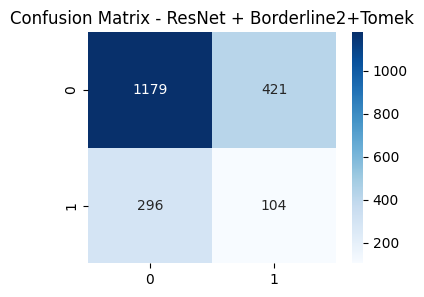

✓ Done: ResNet + Borderline2 + Tomek


In [13]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('ResNet + Borderline2 + Tomek Links')
print("-" * 30)

best_model_resnet_bl_tomek = None
best_score_resnet_bl_tomek = 0
best_fold_idx_resnet_bl_tomek = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    bl = BorderlineSMOTE(kind='borderline-2', random_state=42)
    X_res, y_res = bl.fit_resample(X_fold_train, y_fold_train)
    tl = TomekLinks()
    X_res, y_res = tl.fit_resample(X_res, y_res)
    
    model = create_resnet_model(X_res.shape[1])
    model.fit(X_res, y_res, validation_data=(X_fold_val, y_fold_val),
              epochs=50, batch_size=32, verbose=0,
              callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f}")
    
    if accuracy > best_score_resnet_bl_tomek:
        best_score_resnet_bl_tomek = accuracy
        best_model_resnet_bl_tomek = model
        best_fold_idx_resnet_bl_tomek = fold

print(f"Selected model from fold {best_fold_idx_resnet_bl_tomek} for test evaluation")
y_pred_proba = best_model_resnet_bl_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
print('--- Test Set Performance ---')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ResNet + Borderline2+Tomek')
plt.show()

resnet_bl_tomek_results = {
    'Model': 'ResNet', 'Sampling': f'Borderline2 + Tomek (Fold {best_fold_idx_resnet_bl_tomek})',
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred), 'Recall': recall_score(y_test, y_pred),
    'F1_Score': f1_score(y_test, y_pred), 'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
    'TP': confusion_matrix(y_test, y_pred).ravel()[3], 'TN': confusion_matrix(y_test, y_pred).ravel()[0],
    'FP': confusion_matrix(y_test, y_pred).ravel()[1], 'FN': confusion_matrix(y_test, y_pred).ravel()[2]
}
best_model_resnet_bl_tomek.save('resnet/models/ResNet_bltomek_bestfold.h5')
print("✓ Done: ResNet + Borderline2 + Tomek")

🏆 FINAL COMPARISON TABLE - ResNet (Sorted by Recall)


,Model,Sampling,CV_Accuracy,CV_Std,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,TN,FP,FN
0,ResNet,SMOTEENN (Fold 5),0.263750,0.038314,0.3020,0.203924,0.8575,0.329491,0.504552,343,261,1339,57
1,ResNet,ClusterCentroids (Fold 2),0.412625,0.042131,0.4820,0.214029,0.5950,0.314815,0.527879,238,726,874,162
2,ResNet,NearMiss (Fold 2),0.521750,0.075645,0.5970,0.214085,0.3800,0.273874,0.515031,152,1042,558,248
3,ResNet,Borderline2 + Tomek (Fold 4),0.596000,0.029714,0.6415,0.198095,0.2600,0.224865,0.496631,104,1179,421,296
4,ResNet,ADASYN + Tomek (Fold 5),0.645750,0.027167,0.6650,0.206522,0.2375,0.220930,0.510813,95,1235,365,305
5,ResNet,SMOTE (Fold 2),0.640375,0.028665,0.6700,0.209821,0.2350,0.221698,0.518625,94,1246,354,306
6,ResNet,ADASYN (Fold 2),0.653250,0.017759,0.6510,0.188285,0.2250,0.205011,0.470952,90,1212,388,310
7,ResNet,RandomUnderSampler (Fold 2),0.554500,0.099885,0.6860,0.198413,0.1875,0.192802,0.481036,75,1297,303,325
8,ResNet,SMOTETomek (Fold 5),0.676000,0.028167,0.6885,0.161094,0.1325,0.145405,0.478489,53,1324,276,347
9,ResNet,None (Baseline),0.800000,0.000000,0.8000,0.000000,0.0000,0.000000,0.463739,0,1600,0,400


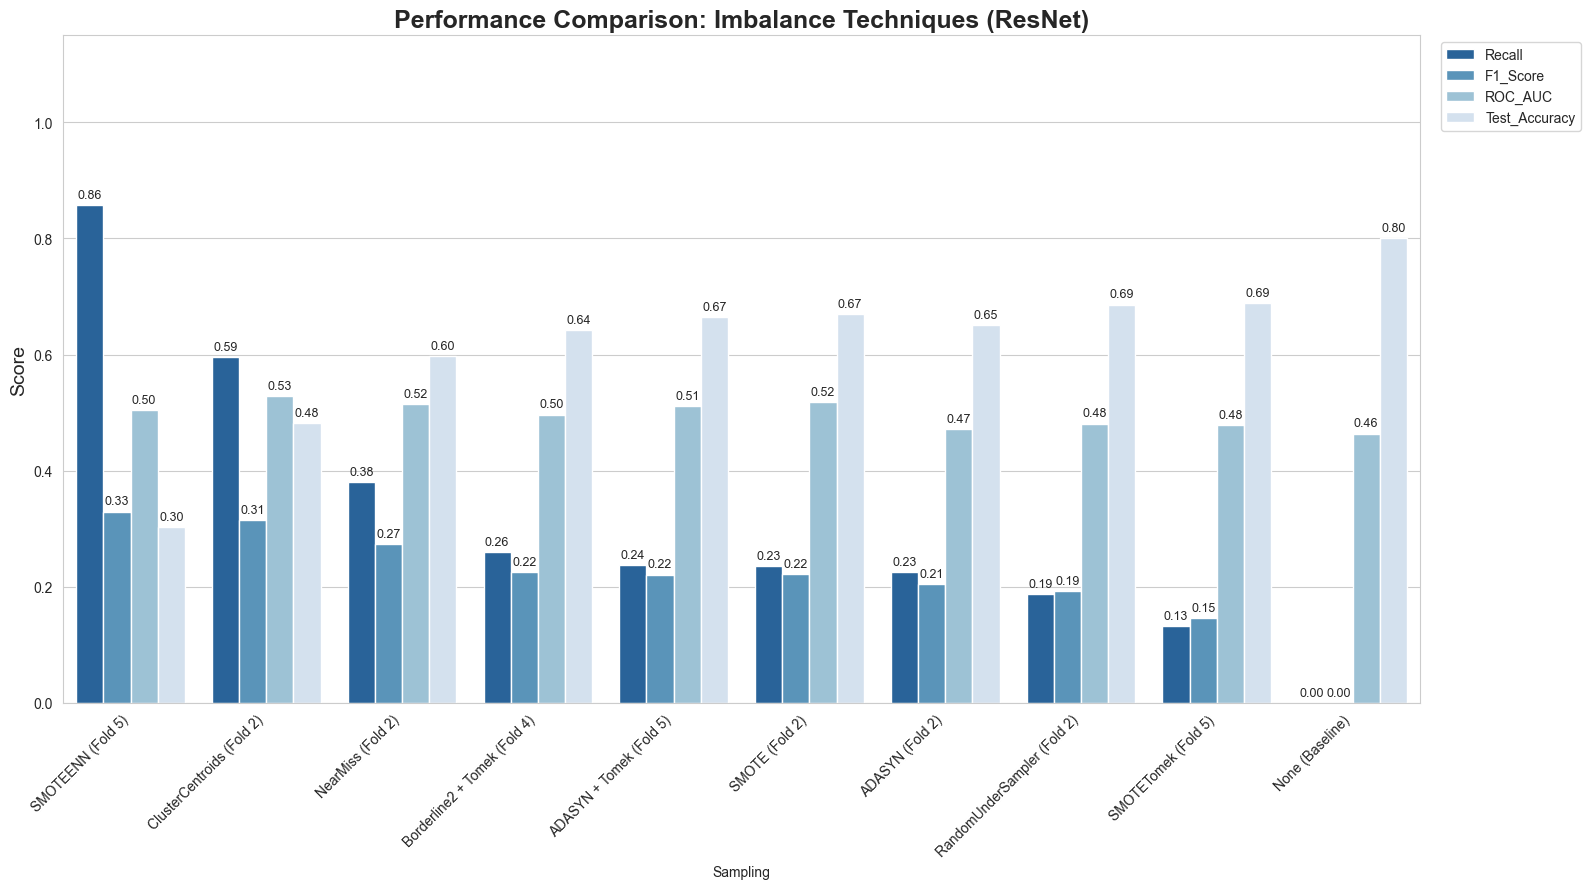

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

resnet_all_results = [
    resnet_baseline_results,
    resnet_smote_results,
    resnet_adasyn_results,
    resnet_rus_results,
    resnet_nearmiss_results,
    resnet_cc_results,
    resnet_smt_results,
    resnet_sme_results,
    resnet_ada_tomek_results,
    resnet_bl_tomek_results
]

df_resnet_results = pd.DataFrame(resnet_all_results)
df_resnet_results = df_resnet_results.sort_values(by='Recall', ascending=False).reset_index(drop=True)

print("=" * 80)
print("🏆 FINAL COMPARISON TABLE - ResNet (Sorted by Recall)")
print("=" * 80)
display(df_resnet_results)

df_resnet_results.to_csv('resnet/resnet_technique_comparison.csv', index=False)

plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")
metrics_to_plot = ['Recall', 'F1_Score', 'ROC_AUC', 'Test_Accuracy']
df_melted = df_resnet_results.melt(id_vars='Sampling', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_melted, x='Sampling', y='Score', hue='Metric', palette='Blues_r')
plt.title('Performance Comparison: Imbalance Techniques (ResNet)', fontsize=18, fontweight='bold')
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.ylim(0, 1.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('resnet/models/resnet_technique_comparison_chart.png', dpi=300)
plt.show()